# Programação linear

A Programação Linear (PL) aprimora a resolução de sistemas de equações lineares ao incorporar uma função-objetivo a ser maximizada ou minimizada. Para $n$ variáveis e $m$ restrições, temos.

\begin{equation}
\text{max (or min)} \sum_{j=i}^{n} c_j x_j
\end{equation}

sujeito a:

\begin{equation}
\text{max (or min)} \sum_{j=i}^{n} a_ij x_j \leq (\text{ou =, ou} \geq) a_i \text{ para } i=1,...,m \text{ e } a_j \geq 0
\end{equation}


## Exemplo 1: Problema de alocação de terras

Uma propriedade apresenta dois talhões florestais aptos para corte: talhão A com $\text{40 }ha$ e $\text{84 }m^3/ha$ de madeira disponíveis; e talhão B com $\text{18 }ha$ e uma produção de $\text{112 }m^3/ha$. O custo por hectare para a administração da venda de madeira é de $\text{R\$ }300$, e a disponibilidade de capital é de $\text{R\$ } 15.000$. Ambos os talhões permitem o desenvolvimento de atividades recreacionistas. Anualmente, o talhão 1 é capaz de sustentar $\text{480 } visitantes/ha$ e o talhão B apresenta capacidade para $\text{1.920 }visitantes/ha$. A propriedade deve ser capaz de receber no mínimo $\text{10.000 }visitantes/ano$. Naturalmente, cada hectare cortado fica inutilizado para atividades de recreação. O problema é determinar quantos hectares explorar em cada talhão de forma a maximizar o volume de madeira cortada.

O problema pode ser resolvido da seguinte forma: 

O objetivo é maximizar o corte de madeira: $max(Z) = 84 \times A + 112 \times B$

Alternativas: exploração dos talhões A e B. 

Restrições: 
1. Área finita dos talhões A e B: $A \leq 40$ e $B \leq 18$
2. Caixa disponível: $300 \times A + 300 \times B \leq 15.000$
3. Recreação: $400 \times (40-A) + 1920 \times (18-B) \geq 10.000$
4. Positividade das alternativas: $A, B \geq 0$

Chamando as alternativas de A e B, em que:

A = número de hectares a serem explorados no talhão A;

B = número de hectares a serem explorados no talhão B. 

Referência: CAIXETA FILHO, J.V. **Pesquisa operacional**: Técnicas de otimização aplicadas a sistemas agroindustriais. São Paulo: Átlas, 2001, 171 p.

In [ ]:
!pip install pulp

In [32]:
# Importar biblioteca
import pulp

# Instanciar o problema de otimização
modelo = pulp.LpProblem("Problema de maximização", pulp.LpMaximize)
A = pulp.LpVariable('A', lowBound=0, cat='Continuous')
B = pulp.LpVariable('B', lowBound=0, cat='Continuous')
# cat='Integer' se for necessário que as variáveis sejam inteiras


# Função objetivo
modelo += 84 * A + 112 * B, "Volume de madeira cortada"

# Restrições
modelo += A <= 40
modelo += B <= 18
modelo += 300*A+300*B <= 15000
modelo += 400*(40-A)+1920*(18-B) >= 10000
modelo += A>=0
modelo += B>=0

# Resolver o problema
modelo.solve()
pulp.LpStatus[modelo.status]

# Exibir os valores das variáveis de decisão
print("Talhão A = {}".format(A.varValue))
print("Talhão B = {}".format(B.varValue))

# Exibir o valor da função objetivo
print(pulp.value(modelo.objective))

Talhão A = 36.473684
Talhão B = 13.526316
4578.7368480000005


### Exibir gráfico

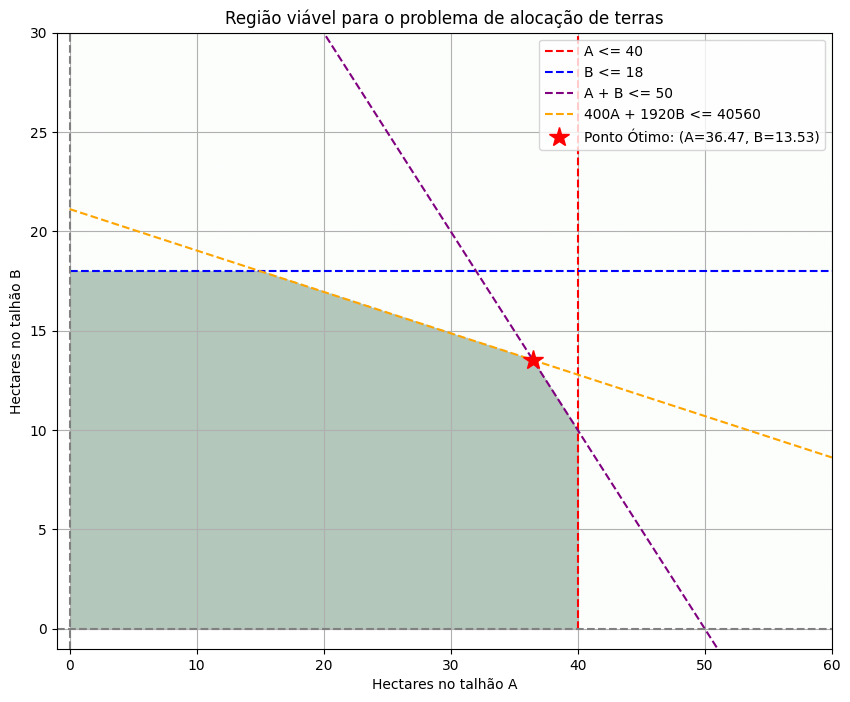

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Definir os limites para A e B
valorA = np.linspace(0, 60, 500)  # Valor máximo de A é 40, mas estendendo um pouco para melhor visualização
valorB = np.linspace(0, 30, 500)  # Valor máximo de B é 18, mas estendendo um pouco para melhor visualização

A, B = np.meshgrid(valorA, valorB)

# Dfinir inequações para melhor visualização da região viável
# 1. A <= 40
# 2. B <= 18
# 3. 300*A + 300*B <= 15000  => A + B <= 50
# 4. 400*(40-A) + 1920*(18-B) >= 10000
#    16000 - 400*A + 34560 - 1920*B >= 10000
#    50560 - 400*A - 1920*B >= 10000
#    40560 >= 400*A + 1920*B
#    400*A + 1920*B <= 40560
# 5. A >= 0
# 6. B >= 0

# Create a boolean array for each constraint
restircao1 = (A <= 40)
restircao2 = (B <= 18)
restircao3 = (A + B <= 50)
restircao4 = (400 * A + 1920 * B <= 40560)
restircao5 = (A >= 0)
restircao6 = (B >= 0)

# Combine all constraints to find the feasible region
feasible_region = restircao1 & restircao2 & restircao3 & restircao4 & restircao5 & restircao6

# Plotar figura
plt.figure(figsize=(10, 8))

# Destacar a região viável
plt.imshow(feasible_region.astype(int), origin='lower',
           extent=[valorA.min(), valorA.max(), valorB.min(), valorB.max()],
           cmap='Greens', alpha=0.3, aspect='auto')

# Plot boundary lines
# A <= 40
plt.plot([40, 40], [0, max(valorB)], color='red', linestyle='--', label='A <= 40')
# B <= 18
plt.plot([0, max(valorA)], [18, 18], color='blue', linestyle='--', label='B <= 18')
# A + B <= 50 => B = 50 - A
plt.plot(valorA, 50 - valorA, color='purple', linestyle='--', label='A + B <= 50')
# 400*A + 1920*B <= 40560 => B = (40560 - 400*A) / 1920
plt.plot(valorA, (40560 - 400 * valorA) / 1920, color='orange', linestyle='--', label='400A + 1920B <= 40560')
# A >= 0
plt.axvline(x=0, color='gray', linestyle='--')
# B >= 0
plt.axhline(y=0, color='gray', linestyle='--')

# Adicionar o ponto ótimo encontrado
otimoA = 36.473684
otimoB = 13.526316
plt.plot(otimoA, otimoB, 'r*', markersize=15, label=f'Ponto Ótimo: (A={otimoA:.2f}, B={otimoB:.2f})')

plt.xlim(-1, 60)
plt.ylim(-1, 30)
plt.xlabel('Hectares no talhão A')
plt.ylabel('Hectares no talhão B')
plt.title('Região viável para o problema de alocação de terras')
plt.legend()
plt.grid(True)
plt.show()

## Exemplo 2: Problema de formulação de ração

Para fornecer $\text{1 } kg$ de ração balanceada a frangos de corte é necessário que a mesma contenha, no mínimo, $17,16%$ de proteína e $\text{3.000 }kcal$ de energia metabolizável aparente. Admite-se que estejam disponíveis para a formulação da ração apenas milho, ao preço de $\text{R\$ }1,80/kg$, e farelo de soja, ao preço de $\text{R\$ }4,20/kg$. O milho contém $8,51%$ de proteína e $\text{3.146 }kcal$ de energia por kg. O farelo de soja, por sua vez, contém $45,6%$ de proteína e $\text{2.283 }kcal$ de energia por kg. Pede-se determinar as quantidades de milho e farelo de soja que devem ser misturadas para que o alimento final satisfaça às necessidades alimentares das aves e, ao mesmo tempo, tenha o menor custo possível.

Referência: CAIXETA FILHO, J.V. **Pesquisa operacional**: Técnicas de otimização aplicadas a sistemas agroindustriais. São Paulo: Átlas, 2001, 171 p.

O problema pode ser resolvido da seguinte forma:

O objetivo é minimizar o custo da ração: $max(Z) = 1,80 \times A + 4,20 \times B$

Alternativas: quantidades de milho (A) e farelo de soja (B).

Restrições:
1. A soma dos ingredientes deve resultar em 1 kg: $A + B = 1$
2. A ração deve conter no mínimo 17,16% de proteína: $0,0851 \times A ​+ 0,456 \times B \geq 0,1716$
3. A ração deve conter no mínimo 3000 kcal: $3146 \times A ​+2283 \times B \geq 3000$
4. Positividade das alternativas: $A, B \geq 0$

Chamando as alternativas de A e B, em que:

A = quantidade de milho (kg);

B = quantidade de farelo de soja (kg). 

In [37]:
# Importar biblioteca
import pulp

# Instanciar o problema de otimização
modelo = pulp.LpProblem("Problema de minimização", pulp.LpMinimize)
A = pulp.LpVariable('A', lowBound=0, cat='Continuous')
B = pulp.LpVariable('B', lowBound=0, cat='Continuous')
# cat='Integer' se for necessário que as variáveis sejam inteiras


# Função objetivo
modelo += 1.80 * A + 4.20 * B, "Custo da ração"

# Restrições
modelo += A + B == 1
modelo += 0.0851*A + 0.456*B >= 0.1716
modelo += 3146*A + 2283*B >= 3000
modelo += A>=0
modelo += B>=0

# Resolver o problema
modelo.solve()
pulp.LpStatus[modelo.status]

# Exibir os valores das variáveis de decisão
print("Quantidade de milho = {}".format(A.varValue))
print("Quantidade de farelo de soja = {}".format(B.varValue))

# Exibir o valor da função objetivo
print(pulp.value(modelo.objective))

Quantidade de milho = 0.7667835
Quantidade de farelo de soja = 0.2332165
2.3597196
